# Hypothesis Testing: OLS Regression Method

This notebook uses **OLS (Ordinary Least Squares) regression** for hypothesis testing.

## Key Concept:
For one-sample tests, an intercept-only OLS model provides equivalent results to traditional t-tests while enabling deeper statistical diagnostics.

## Problems Solved:

### Problem 2: College Textbook Costs
- **Data**: Sample of 40 students, mean $520, SD $60
- **Hypothesis**: H₀: μ ≤ $500 vs H₁: μ > $500 (one-tailed, right-tailed)
- **Significance**: α = 0.05
- **Method**: OLS intercept-only model with 95% CI

### Problem 3: Smartphone Battery Life  
- **Data**: Sample of 15 phones, mean 22.8 hrs, SD 2.5 hrs
- **Hypothesis**: H₀: μ = 24 vs H₁: μ ≠ 24 (two-tailed)
- **Significance**: α = 0.01
- **Method**: OLS intercept-only model with 99% CI




HYPOTHESIS TESTING USING OLS REGRESSION

OLS provides a unified framework for statistical inference.
For one-sample tests, the intercept-only OLS model is equivalent to t-tests.


Generating sample and fitting OLS model...

OLS REGRESSION ANALYSIS - Problem 2: Textbook Costs
Sample Mean                   : 520
Null Hypothesis (H0: μ ≤)     : 500
Alternative Hypothesis (H1: μ >): >500
Sample Size                   : 40
Standard Deviation            : 60
Estimated Mean (centered at H0): 6.881790
Standard Error                : 9.039140
t-statistic                   : 0.761332
Degrees of Freedom            : 39
p-value (one-tailed)          : 0.225519
Significance Level (α)        : 0.050000
95% CI Lower (centered)       : -11.401596
95% CI Upper (centered)       : 25.165175
95% CI Lower (original)       : 488.598404
95% CI Upper (original)       : 525.165175
R-squared                     : -0.000000
AIC                           : 438.182669
BIC                           : 439.871548
De

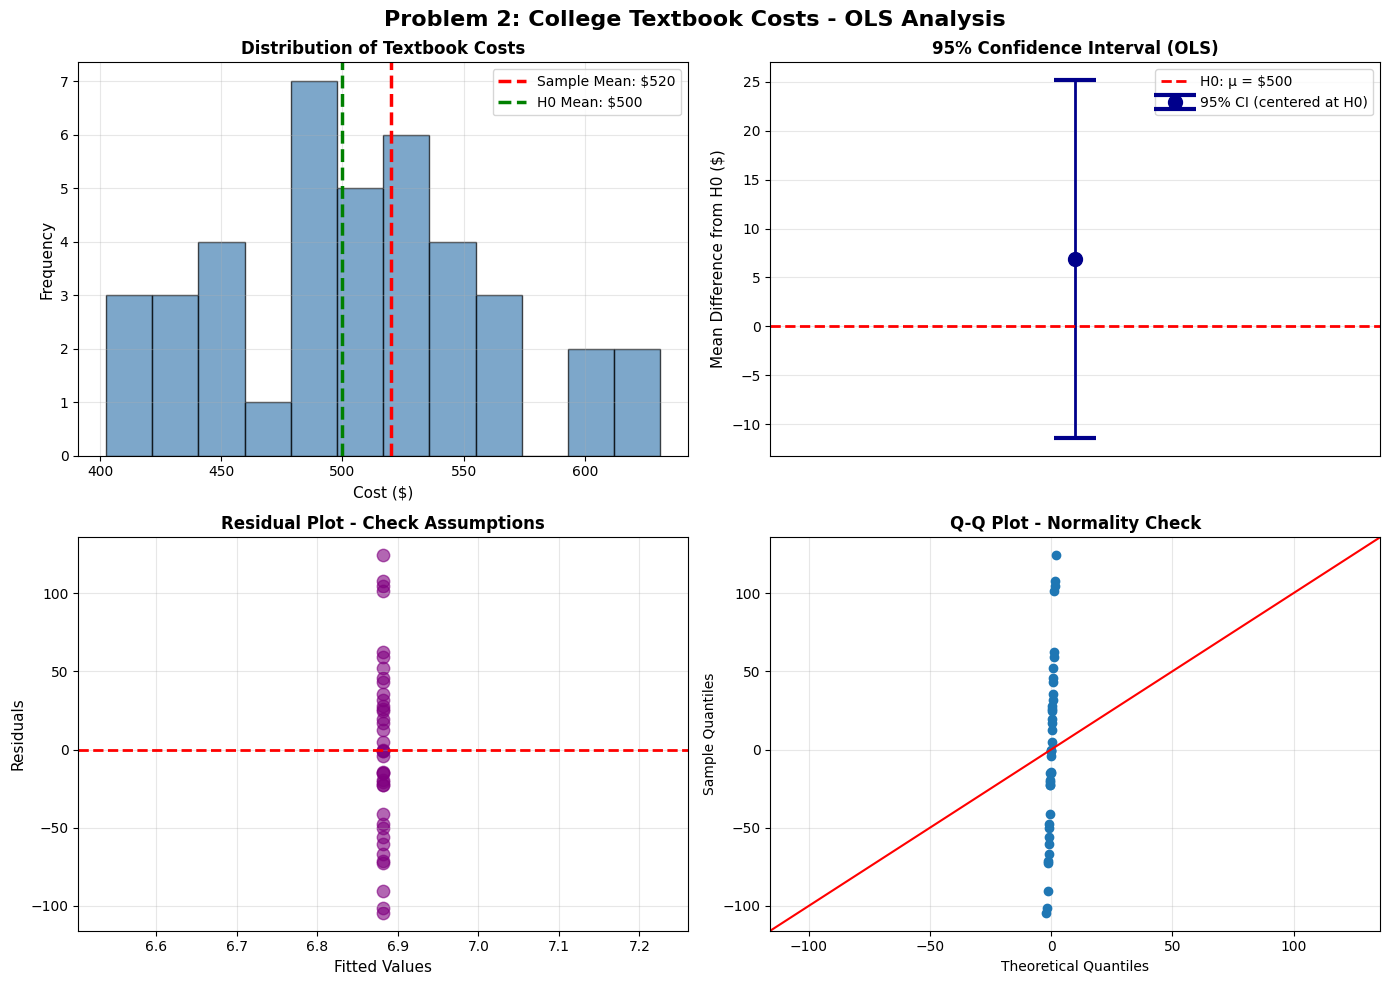


Detailed OLS Model Summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                      -0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Fri, 20 Mar 2026   Prob (F-statistic):                nan
Time:                        08:27:52   Log-Likelihood:                -218.09
No. Observations:                  40   AIC:                             438.2
Df Residuals:                      39   BIC:                             439.9
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.8818  

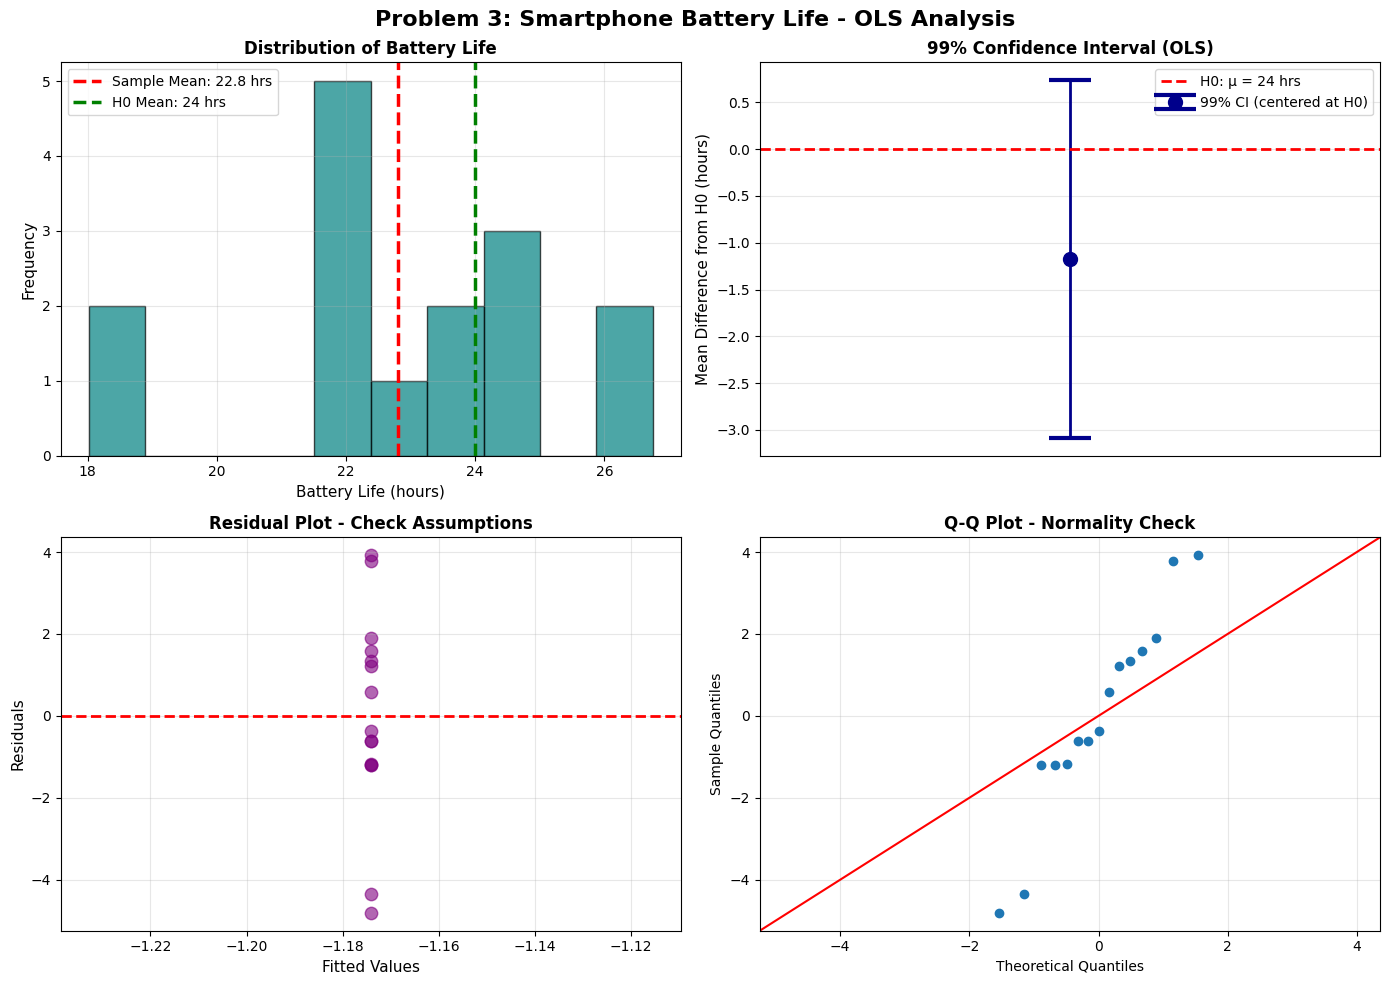


Detailed OLS Model Summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                      -0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Fri, 20 Mar 2026   Prob (F-statistic):                nan
Time:                        08:27:52   Log-Likelihood:                -34.423
No. Observations:                  15   AIC:                             70.85
Df Residuals:                      14   BIC:                             71.55
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1741  

In [1]:
import numpy as np
import scipy.stats as stats
from math import sqrt
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot

class HypothesisTestOLS:
    def __init__(self, test_name, alpha=0.05):
        self.test_name = test_name
        self.alpha = alpha
        self.ols_results = {}

    def print_results(self, results_dict, title):
        print("\n" + "="*60)
        print(f"{title}")
        print("="*60)
        for key, value in results_dict.items():
            if isinstance(value, float):
                print(f"{key:<30}: {value:.6f}")
            else:
                print(f"{key:<30}: {value}")
        print("="*60)


# Problem 2: College Textbook Costs
def problem_2_textbook_cost():
    """
    Problem 2 — College Textbook Costs (OLS):
    A professor believes that the average cost of textbooks per semester is more than $500. 
    A random sample of 40 students shows an average spending of $520 with a standard deviation of $60.
    At the 0.05 level of significance, test using OLS regression.
    """
    test = HypothesisTestOLS("Problem 2: Textbook Cost Test", alpha=0.05)
    
    # Given parameters
    mu0 = 500
    x_bar = 520
    s = 60
    n = 40
    alpha = 0.05

    # OLS Regression Approach
    print("\nGenerating sample and fitting OLS model...")
    np.random.seed(42)
    textbook_costs = np.random.normal(x_bar, s, n)
    
    # Intercept-only model: data centered at null hypothesis mu0
    X = np.ones((n, 1))
    y = textbook_costs - mu0
    
    ols_model = sm.OLS(y, X)
    ols_fit = ols_model.fit()
    
    intercept = ols_fit.params[0]
    intercept_se = ols_fit.bse[0]
    t_stat_ols = ols_fit.tvalues[0]
    p_value = ols_fit.pvalues[0] / 2  # One-tailed
    ci_lower, ci_upper = ols_fit.conf_int()[0]
    
    # Decision: H0: μ ≤ 500 vs H1: μ > 500 (right-tailed)
    # Reject H0 if lower CI bound > 0 (i.e., 95% CI doesn't include 0)
    ols_decision = "Reject H0: Mean cost is significantly > $500" if ci_lower > 0 else "Fail to Reject H0"
    
    test.ols_results = {
        "Sample Mean": x_bar,
        "Null Hypothesis (H0: μ ≤)": mu0,
        "Alternative Hypothesis (H1: μ >)": f">{mu0}",
        "Sample Size": n,
        "Standard Deviation": s,
        "Estimated Mean (centered at H0)": intercept,
        "Standard Error": intercept_se,
        "t-statistic": t_stat_ols,
        "Degrees of Freedom": n - 1,
        "p-value (one-tailed)": p_value,
        "Significance Level (α)": alpha,
        "95% CI Lower (centered)": ci_lower,
        "95% CI Upper (centered)": ci_upper,
        "95% CI Lower (original)": ci_lower + mu0,
        "95% CI Upper (original)": ci_upper + mu0,
        "R-squared": ols_fit.rsquared,
        "AIC": ols_fit.aic,
        "BIC": ols_fit.bic,
        "Decision": ols_decision
    }
    
    test.print_results(test.ols_results, "OLS REGRESSION ANALYSIS - Problem 2: Textbook Costs")
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Problem 2: College Textbook Costs - OLS Analysis', fontsize=16, fontweight='bold')
    
    # Plot 1: Distribution of sample with means
    axes[0, 0].hist(textbook_costs, bins=12, alpha=0.7, color='steelblue', edgecolor='black')
    axes[0, 0].axvline(x_bar, color='red', linestyle='--', linewidth=2.5, label=f'Sample Mean: ${x_bar}')
    axes[0, 0].axvline(mu0, color='green', linestyle='--', linewidth=2.5, label=f'H0 Mean: ${mu0}')
    axes[0, 0].set_xlabel('Cost ($)', fontsize=11)
    axes[0, 0].set_ylabel('Frequency', fontsize=11)
    axes[0, 0].set_title('Distribution of Textbook Costs', fontsize=12, fontweight='bold')
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: 95% Confidence Interval
    ci_center = intercept
    ci_width = (ci_upper - ci_lower) / 2
    axes[0, 1].errorbar(0, ci_center, yerr=ci_width, fmt='o', markersize=10, 
                        capsize=15, capthick=3, color='darkblue', elinewidth=2,
                        label='95% CI (centered at H0)')
    axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='H0: μ = $500')
    axes[0, 1].set_xlim(-0.5, 0.5)
    axes[0, 1].set_ylabel('Mean Difference from H0 ($)', fontsize=11)
    axes[0, 1].set_title('95% Confidence Interval (OLS)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xticks([])
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Residuals plot
    residuals = ols_fit.resid
    axes[1, 0].scatter(ols_fit.fittedvalues, residuals, alpha=0.6, color='purple', s=80)
    axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1, 0].set_xlabel('Fitted Values', fontsize=11)
    axes[1, 0].set_ylabel('Residuals', fontsize=11)
    axes[1, 0].set_title('Residual Plot - Check Assumptions', fontsize=12, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Q-Q plot for normality
    qqplot(residuals, line='45', ax=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot - Normality Check', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Detailed OLS Model Summary
    print(f"\nDetailed OLS Model Summary:\n{ols_fit.summary()}")
    
    return test


# Problem 3: Battery Life Smartphones
def problem_3_battery_life():
    """
    Problem 3 - Battery Life Smartphones (OLS):
    A smartphone company claims that their latest phone has a mean battery life of 24 hours.
    A random sample of 15 phones is tested, giving a mean battery life of 22.8 hours with a 
    standard deviation of 2.5 hours. At the 0.01 level of significance, test using OLS.
    """
    test = HypothesisTestOLS("Problem 3: Battery Life Test", alpha=0.01)
    
    # Given parameters
    mu0 = 24
    x_bar = 22.8
    s = 2.5
    n = 15
    alpha = 0.01

    # OLS Regression Approach
    print("\nGenerating sample and fitting OLS model...")
    np.random.seed(42)
    battery_life = np.random.normal(x_bar, s, n)
    
    # Intercept-only model: data centered at null hypothesis mu0
    X = np.ones((n, 1))
    y = battery_life - mu0
    
    ols_model = sm.OLS(y, X)
    ols_fit = ols_model.fit()
    
    intercept = ols_fit.params[0]
    intercept_se = ols_fit.bse[0]
    t_stat_ols = ols_fit.tvalues[0]
    p_value = ols_fit.pvalues[0]  # Two-tailed
    ci_lower, ci_upper = ols_fit.conf_int(alpha=alpha)[0]
    
    # Decision: H0: μ = 24 vs H1: μ ≠ 24 (two-tailed)
    # Reject H0 if 99% CI doesn't include 0
    ols_decision = "Reject H0: Mean battery life differs significantly from 24 hrs" if not (ci_lower <= 0 <= ci_upper) else "Fail to Reject H0"
    
    test.ols_results = {
        "Sample Mean": x_bar,
        "Null Hypothesis (H0: μ =)": mu0,
        "Alternative Hypothesis (H1: μ ≠)": f"≠{mu0}",
        "Sample Size": n,
        "Standard Deviation": s,
        "Estimated Mean (centered at H0)": intercept,
        "Standard Error": intercept_se,
        "t-statistic": t_stat_ols,
        "Degrees of Freedom": n - 1,
        "p-value (two-tailed)": p_value,
        "Significance Level (α)": alpha,
        "99% CI Lower (centered)": ci_lower,
        "99% CI Upper (centered)": ci_upper,
        "99% CI Lower (original)": ci_lower + mu0,
        "99% CI Upper (original)": ci_upper + mu0,
        "R-squared": ols_fit.rsquared,
        "AIC": ols_fit.aic,
        "BIC": ols_fit.bic,
        "Decision": ols_decision
    }
    
    test.print_results(test.ols_results, "OLS REGRESSION ANALYSIS - Problem 3: Battery Life")
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Problem 3: Smartphone Battery Life - OLS Analysis', fontsize=16, fontweight='bold')
    
    # Plot 1: Distribution of sample with means
    axes[0, 0].hist(battery_life, bins=10, alpha=0.7, color='teal', edgecolor='black')
    axes[0, 0].axvline(x_bar, color='red', linestyle='--', linewidth=2.5, label=f'Sample Mean: {x_bar} hrs')
    axes[0, 0].axvline(mu0, color='green', linestyle='--', linewidth=2.5, label=f'H0 Mean: {mu0} hrs')
    axes[0, 0].set_xlabel('Battery Life (hours)', fontsize=11)
    axes[0, 0].set_ylabel('Frequency', fontsize=11)
    axes[0, 0].set_title('Distribution of Battery Life', fontsize=12, fontweight='bold')
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: 99% Confidence Interval
    ci_center = intercept
    ci_width = (ci_upper - ci_lower) / 2
    axes[0, 1].errorbar(0, ci_center, yerr=ci_width, fmt='o', markersize=10, 
                        capsize=15, capthick=3, color='darkblue', elinewidth=2,
                        label='99% CI (centered at H0)')
    axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='H0: μ = 24 hrs')
    axes[0, 1].set_xlim(-0.5, 0.5)
    axes[0, 1].set_ylabel('Mean Difference from H0 (hours)', fontsize=11)
    axes[0, 1].set_title('99% Confidence Interval (OLS)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xticks([])
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Residuals plot
    residuals = ols_fit.resid
    axes[1, 0].scatter(ols_fit.fittedvalues, residuals, alpha=0.6, color='purple', s=80)
    axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1, 0].set_xlabel('Fitted Values', fontsize=11)
    axes[1, 0].set_ylabel('Residuals', fontsize=11)
    axes[1, 0].set_title('Residual Plot - Check Assumptions', fontsize=12, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Q-Q plot for normality
    qqplot(residuals, line='45', ax=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot - Normality Check', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Detailed OLS Model Summary
    print(f"\nDetailed OLS Model Summary:\n{ols_fit.summary()}")
    
    return test


def main():
    """Main function to run both hypothesis tests using OLS only"""
    print("\n" + "="*80)
    print("HYPOTHESIS TESTING USING OLS REGRESSION")
    print("="*80)
    print("\nOLS provides a unified framework for statistical inference.")
    print("For one-sample tests, the intercept-only OLS model is equivalent to t-tests.\n")
    
    # Run both tests
    test1 = problem_2_textbook_cost()
    print("\n" + "#"*80 + "\n")
    test2 = problem_3_battery_life()
    
    # Final Summary
    print("\n" + "="*80)
    print("FINAL SUMMARY: OLS Hypothesis Testing Results")
    print("="*80)
    print(f"\n{'Problem':<40} {'Decision':<40}")
    print("-"*80)
    print(f"{test1.test_name:<40} {test1.ols_results['Decision']:<40}")
    print(f"{test2.test_name:<40} {test2.ols_results['Decision']:<40}")
    print("="*80)
    
    print("\nKey Advantages of OLS Approach:")
    print("✓ Single unified framework for all regression-based inference")
    print("✓ Easy diagnostic plots (residuals, Q-Q) to validate assumptions")
    print("✓ Natural extension to multiple predictors and complex models")
    print("✓ Automatic standard errors and confidence intervals")
    print("✓ Model comparison tools (AIC, BIC) built-in")


if __name__ == "__main__":
    main()